In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
box_img = cv.imread('../../../class.vision/images/box.png')
box_in_scene_img = cv.imread('../../../class.vision/images/box_in_scene.png')

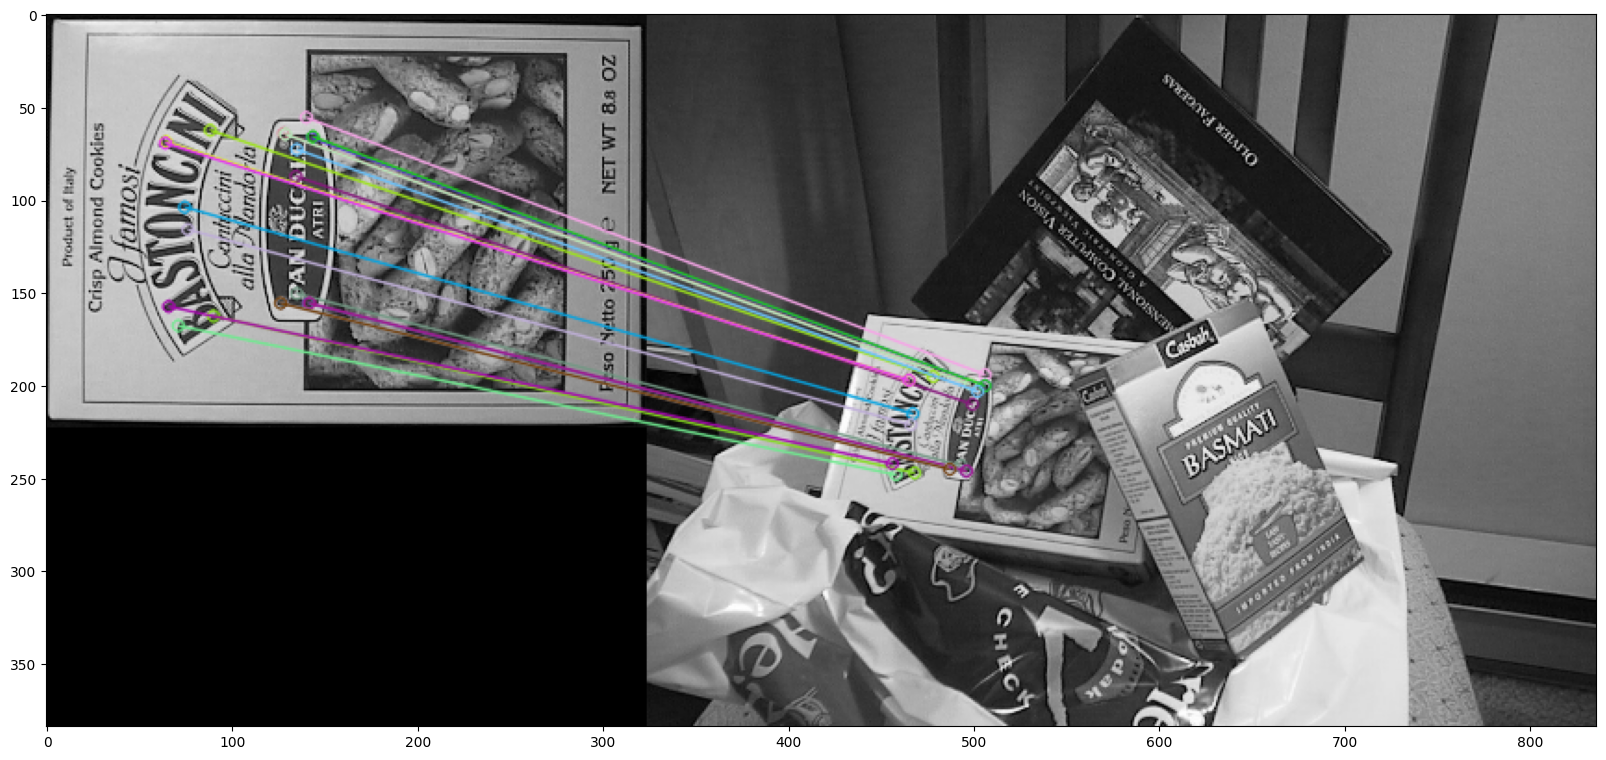


Number of Matching Keypoints Between The Training and Query Images:  453


In [3]:
# Initiate SIFT detector
orb = cv.ORB_create()
# find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(box_img,None)
kp2, des2 = orb.detectAndCompute(box_in_scene_img,None)

# create BFMatcher object
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck = False)

# Match descriptors.
matches = bf.match(des1,des2)
# Sort them in the order of their distance.
matches = sorted(matches, key = lambda x:x.distance)
# Draw first 10 matches.
img_result = cv.drawMatches(box_img,kp1,box_in_scene_img,kp2,matches[:20],None,flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=[20,10])
plt.imshow(img_result[...,::-1]),plt.show();
print("\nNumber of Matching Keypoints Between The Training and Query Images: ", len(matches))